# Cellpose Segmentation

Run cellpose directly on LBM data using `lsp.cellpose()`.

In [1]:
!uv pip install ../../../mbo_utilities

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 209 packages in 457ms
   Building mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
      Built mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
Prepared 1 package in 1.31s
Uninstalled 1 package in 9ms
Installed 1 package in 16ms
 - mbo-utilities==2.4.0
 + mbo-utilities==2.4.0 (from file:///C:/Users/RBO/repos/mbo_utilities)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import hsv_to_rgb

import mbo_utilities as mbo
import lbm_suite2p_python as lsp

plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 120

In [3]:
# select paths interactively (or edit manually)

# RAW_PATH = mbo.select_folder(title="Select raw data folder")
RAW_PATH = r"\\Rbo-w1\d\W1_DATA\wsnyder\2025-10-16-Females-Shank-Wheel-316902\5\planes\suite2p"
OUTPUT_DIR = Path(r"D:/output/cellpose/reg")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input: {RAW_PATH}")
print(f"Output: {OUTPUT_DIR}")

Input: \\Rbo-w1\d\W1_DATA\wsnyder\2025-10-16-Females-Shank-Wheel-316902\5\planes\suite2p
Output: D:\output\cellpose\reg


In [ ]:
#!uv run mbo D:\W2_DATA/wsynder/

Uninstalled 1 package in 9ms
Installed 1 package in 16ms

Counting frames: 100%|██████████| 49/49 [00:00<00:00, 12251.62it/s]
INFO - mbo.gui - Logger initialized.
INFO - mbo.gui - Data type: MboRawArray, is_mbo_scan: True
INFO - mbo.gui - Starting zstats computation...


In [5]:
# from mbo_utilities.graphics import simple_selector as ss
# # edit these paths
# RAW_PATH = Path(r"\\server\path\to\raw\data")
# OUTPUT_DIR = Path(r"D:/output/cellpose")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# path_selection = ss.select_files()

# print(f"Input: {RAW_PATH}")
# print(f"Output: {OUTPUT_DIR}")

In [6]:
# check data shape
arr = mbo.imread(RAW_PATH, fix_phase=True, use_fft=True)
print(f"Shape: {arr.shape}")
print(f"  frames: {arr.shape[0]}")
print(f"  planes: {arr.shape[1] if len(arr.shape) == 4 else 1}")

Shape: (21880, 14, 594, 458)
  frames: 21880
  planes: 14


## Run Cellpose

In [7]:
# cellpose parameters
DIAMETER = 4              # expected cell diameter in pixels
CELLPROB_THRESHOLD = -6.0 # lower = more cells detected
FLOW_THRESHOLD = 0.0      # flow error threshold
MIN_SIZE = 2              # min pixels per cell
MAX_SIZE_UM = 35          # max cell diameter in microns

results = lsp.cellpose(
    input_data=RAW_PATH,
    save_path=OUTPUT_DIR,
    planes=None,  # None = all planes, or [1, 2] for specific planes
    projection="max",
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_THRESHOLD,
    flow_threshold=FLOW_THRESHOLD,
    min_size=MIN_SIZE,
    max_size_um=MAX_SIZE_UM,
    reader_kwargs={"fix_phase": True, "use_fft": True},
)

print(f"\nTotal cells: {results['n_rois']}")

Cellpose Segmentation
Loading input data...
  Input: \\Rbo-w1\d\W1_DATA\wsnyder\2025-10-16-Females-Shank-Wheel-316902\5\planes\suite2p


model_type argument is not used in v4.0.1+. Ignoring this argument...


  Loaded as: Suite2pVolumeArray

Dataset info:
  Shape: (21880, 14, 594, 458)
  Frames: 21880
  Planes: 14
  Data type: 4D volumetric

Processing plan:
  Planes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Projection: max
  Output: D:\output\cellpose\reg

GPU: enabled

Loading Cellpose model (cpsam)...
  Model loaded in 1.86s

Processing plane 1/14
  Loading existing results...
  Found 20 existing ROIs
  Generating visualization PNGs...

Processing plane 2/14
  Loading existing results...
  Found 34 existing ROIs
  Generating visualization PNGs...

Processing plane 3/14
  Loading existing results...
  Found 39 existing ROIs
  Generating visualization PNGs...

Processing plane 4/14
  Loading existing results...
  Found 38 existing ROIs
  Generating visualization PNGs...

Processing plane 5/14
  Loading existing results...
  Found 40 existing ROIs
  Generating visualization PNGs...

Processing plane 6/14
  Loading existing results...
  Found 46 existing ROIs
  Generating visualizat

## Load Results

In [13]:
# load results for a specific plane (0-indexed)
PLANE = 0
cp = lsp.load_cellpose_results(OUTPUT_DIR, plane_idx=PLANE)
masks = cp["masks"]
proj = cp["projection"]

n_cells = int(masks.max())
print(f"Plane {PLANE}: {n_cells} cells")
print(f"Image: {proj.shape}")

Plane 0: 20 cells
Image: (594, 458)


## View Results

In [9]:
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def mask_overlay(img, masks, alpha=0.4):
    """overlay colored masks on grayscale image"""
    img_norm = normalize99(img)
    rgb = np.stack([img_norm]*3, axis=-1)
    if masks.max() > 0:
        n = masks.max()
        np.random.seed(42)
        colors = np.zeros((n+1, 3))
        for i in range(1, n+1):
            colors[i] = hsv_to_rgb([np.random.rand(), 0.8, 0.9])
        mask_rgb = colors[masks]
        mask_area = masks > 0
        rgb[mask_area] = (1-alpha)*rgb[mask_area] + alpha*mask_rgb[mask_area]
    return np.clip(rgb, 0, 1)

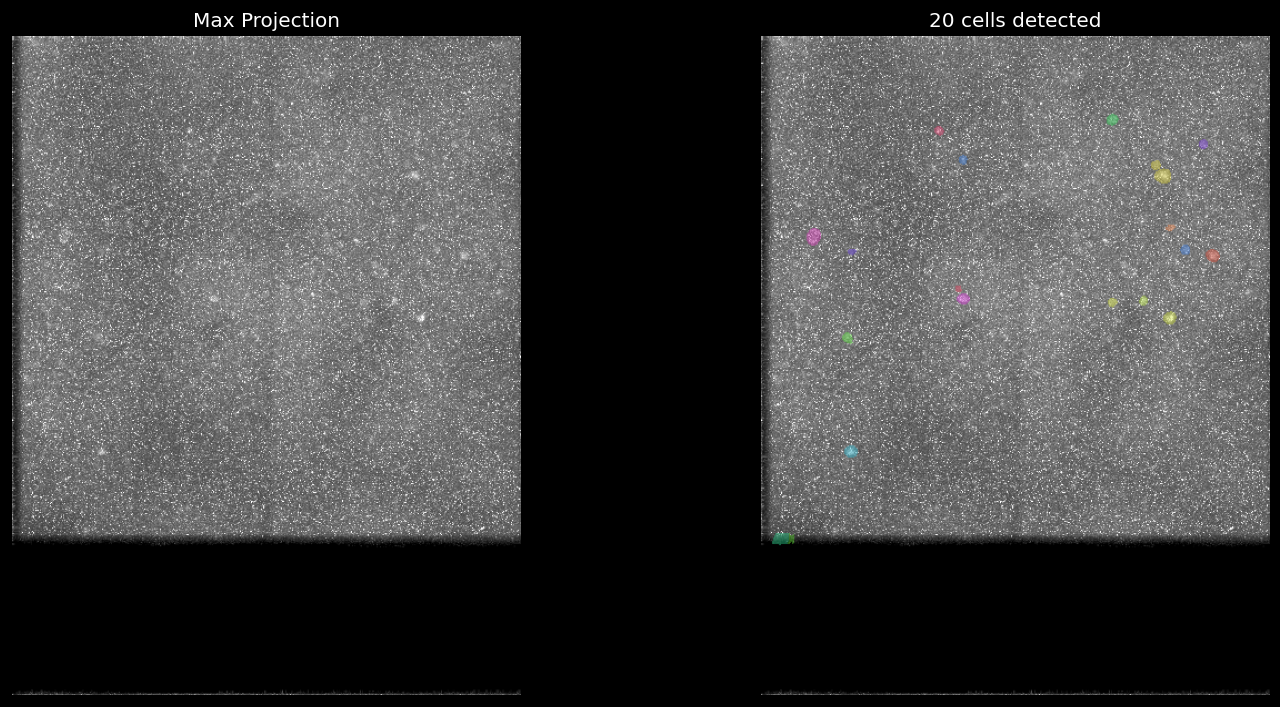

In [10]:
# full field of view
overlay = mask_overlay(proj, masks)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(normalize99(proj), cmap='gray')
axes[0].set_title('Max Projection')
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f'{n_cells} cells detected')
axes[1].axis('off')

plt.tight_layout()
plt.show()

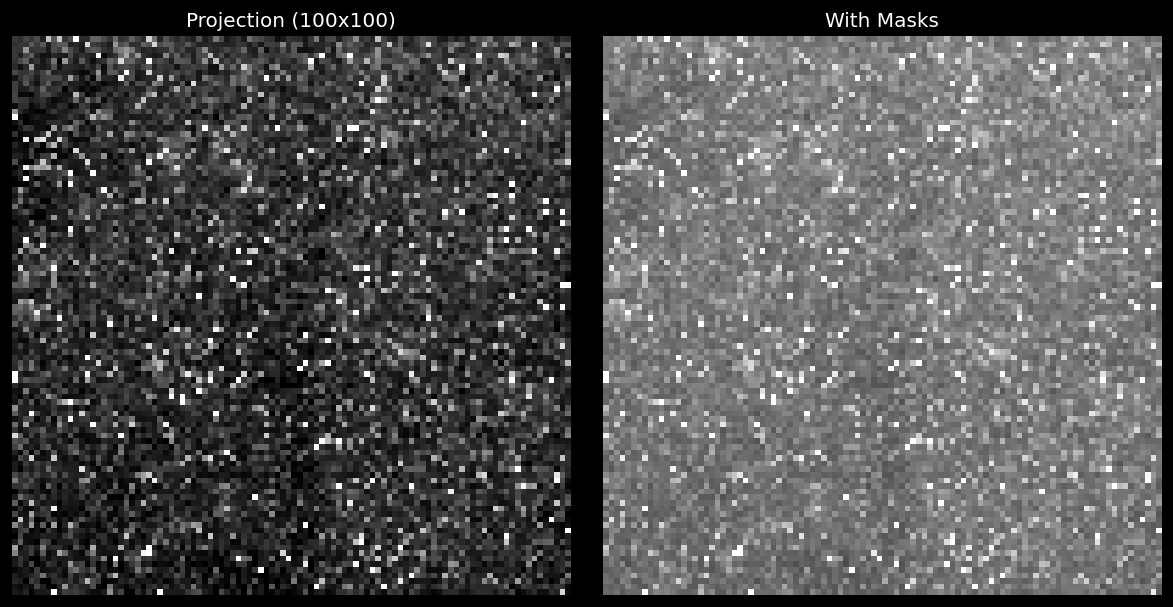

In [11]:
# zoomed view (100x100 from center)
cy, cx = proj.shape[0] // 2, proj.shape[1] // 2
s = 50  # half-size

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(normalize99(proj[cy-s:cy+s, cx-s:cx+s]), cmap='gray')
axes[0].set_title('Projection (100x100)')
axes[0].axis('off')

axes[1].imshow(overlay[cy-s:cy+s, cx-s:cx+s])
axes[1].set_title('With Masks')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Cell Size Distribution

## Summary

In [12]:
print(f"Input: {RAW_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"")
print(f"Parameters:")
print(f"  diameter: {DIAMETER}")
print(f"  cellprob_threshold: {CELLPROB_THRESHOLD}")
print(f"  flow_threshold: {FLOW_THRESHOLD}")
print(f"  min_size: {MIN_SIZE}")
print(f"  max_size_um: {MAX_SIZE_UM}")
print(f"")
print(f"Results:")
print(f"  Cells: {n_cells}")
print(f"  Median diameter: {np.median(diameters):.1f} px")

Input: \\Rbo-w1\d\W1_DATA\wsnyder\2025-10-16-Females-Shank-Wheel-316902\5\planes\suite2p
Output: D:\output\cellpose\reg

Parameters:
  diameter: 4
  cellprob_threshold: -6.0
  flow_threshold: 0.0
  min_size: 2
  max_size_um: 35

Results:
  Cells: 20


NameError: name 'diameters' is not defined